# 3.  Star Catalogues

In this tutorial we 

### Setup notebook

In [13]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [14]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# PlatoSim
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup
setup()

---

## Generate a *custom* star catalog

In [15]:
# Inputs
inputDir    = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles"
inputFile   = inputDir + "/inputfile.yaml"

# Outputs
outputDir      = os.getcwd()
outputFileName = "output_example1"
starcatFile    = outputDir + "/starcat_example1.txt"

In [16]:
# Set up a Simulation object
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

In [17]:
# Turn of jitter
sim["Platform/UseJitter"] = "no"

# Specify the orientation of the platform, telescope, focal plane, etc.
# Do this before creating the star catalog.
sim["ObservingParameters/RApointing"]                 = 180.0 
sim["ObservingParameters/DecPointing"]                = -70.0
sim["ObservingParameters/NumExposures"]               = 10  
sim["Platform/SolarPanelOrientation"]                 = 0.0
sim["Telescope/AzimuthAngle"]                         = 0.0
sim["Telescope/TiltAngle"]                            = 0.0
sim["Camera/FocalPlaneOrientation/Source"]            = "ConstantValue"
sim["Camera/FocalPlaneOrientation/ConstantValue"]     = 5.0
sim["CCD/OriginOffsetX"]                              = 0.0
sim["CCD/OriginOffsetY"]                              = 0.0
sim["CCD/Orientation"]                                = 90.0
sim["Camera/IncludeFieldDistortion"]                  = False
sim["Camera/FocalLength/Source"]                      = "ConstantValue"
sim["Camera/FocalLength/ConstantValue"]               = 0.24712595 
sim["PSF/Model"]                                      = "AnalyticNonGaussian"
sim["PSF/AnalyticNonGaussian/IncludeChargeDiffusion"] = False   

In [18]:
# Specify the pixel coordinates (of the CCD, not of the subfield) of your stars
row = np.array([3007.0, 3030.0, 3015.0])
col = np.array([3040.0, 3045.0, 3005.0])
mag = np.array([11.0, 10.0, 12.0])
starID = [100, 101, 102]

# Create the star catalog file: an ascii file will be written with the columns
# ra, dec, and magnitude.
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

In [19]:
# Make sure the simulation object uses this star catalog
sim["ObservingParameters/StarCatalogFile"] = starcatFile

# Set a subfield around the stars, large enough to contain all of them
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000
sim["SubField/NumColumns"]      = 50
sim["SubField/NumRows"]         = 50

In [20]:
# Run the simulation
simfile = sim.run(removeOutputFile=True)


2022-10-06 23:59:41 WARNING Camera: No point-like ghost positions to write to HDF5 file.



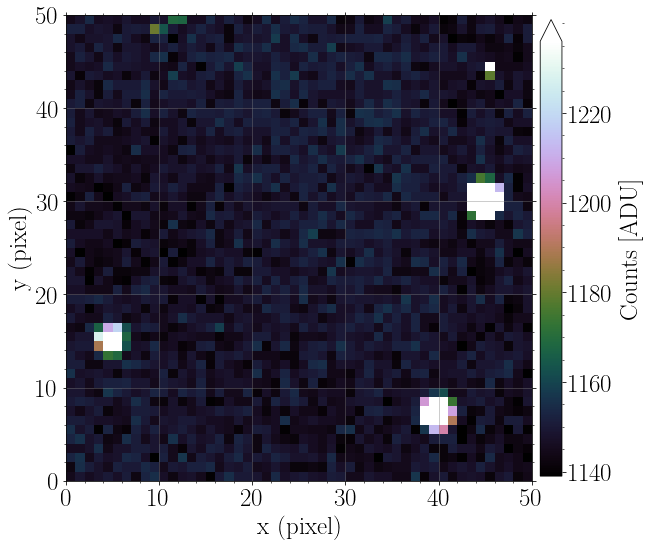

In [21]:
imageNr = 0
fig = simfile.showImage(imageNr, clipPercentile=1, imgScale="clip",  
                  figsize=(10,10), fontSize=25, useTitle=False,
                  showStarPositions=False, showStarIDs=False,
                  colorMap="cubehelix", colorBar=True, showGrid=True) 

---

## Generate a *random* star catalog

With the above definitions we can start simulting a realistic synthetic stellar catalogue. We start by defining some input parameters we want to 

In [22]:
# Change these parameters after use
numStars           = 10
numSubfields       = 5
subfieldDim        = 100
numExposures       = 1
psfModel           = "MappedFromFile"
outputFileName     = outputDir  + "/output_example2_"
filename           = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles/starcatalog.txt"

In this example..

In [23]:
from platosim.distribution import Distribution
from prettytable import PrettyTable

In [24]:
t = PrettyTable()
t.add_column("Distribution utilities", dir(Distribution)[27:])
t

Distribution utilities
expFunction
getMagnitudeDistribution
getRandomMagnitude
getRandomPosition
getStarCatalog
inverseExpFunction
readMagnitudes


In [25]:
dist = Distribution(filename)

We can now use the fix functionality of `Distribution` class.

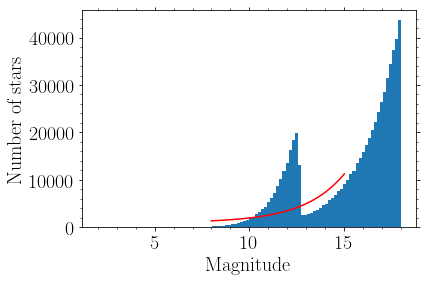

In [26]:
# Star catalogue
rowsCatalog, columnsCatalog, magnitudesCatalog = dist.getStarCatalog(numStars, 8, 15, subfieldDim, plot=True)

In [27]:
rowsCatalog, columnsCatalog, magnitudesCatalog

(array([56.84622309, 70.23625303, 22.83034071, 73.84175653, 38.33253354,
         7.62235634, 86.29590536, 11.3479438 , 97.42609353]),
 array([74.89583504, 77.16156097, 24.87395608, 69.56515726, 69.42648329,
        40.02532332, 69.55706711, 36.49133926, 86.19666465]),
 array([12.56658164, 14.29826665, 13.6981774 , 11.68025335, 14.24492753,
        11.16385859, 13.63012952, 14.64914031, 12.45302534]))

In [29]:
# Sub-field related configuration parameters
# (1) "lowerLeft": in the lower left corner of the CCD (i.e. close to the readout register,
#     small PSF)
# (2) "lowerRight": in the lower right corner of the CCD (i.e. close to the readout register,
#     large PSF)
# (3) "upperLeft": in the upper left corner of the CCD (i.e. far from the readout register,
#     large PSF)
# (4) "middle": in the centre of the CCD (sub-field overlaps with both detector halves)
# (5) "upperRight": in the upper right corner of the CCD (i.e. far from the readout register,
#      large PSF)
subFieldNames = ["output_example2_lowerLeft", "output_example2_lowerRight", 
                 "output_example2_upperLeft", "output_example2_middle", 
                 "output_example2_upperRight"]

# Set subfield dimentions
ccdDimensions         = 4510
subFieldCenterRows    = [subfieldDim/2, subfieldDim/2, ccdDimensions - subfieldDim/2, 
                         ccdDimensions/2, ccdDimensions - subfieldDim/2]
subFieldCenterColumns = [subfieldDim/2, ccdDimensions - subfieldDim/2, 
                         subfieldDim/2, ccdDimensions/2, 
                         ccdDimensions - subfieldDim/2]

In [30]:
for i in range(numSubfields):
    
    sim = Simulation(subFieldNames[i], outputDir=outputDir)
    
    # Obs params   
    sim["ObservingParameters/NumExposures"] = numExposures

    # Camera params
    sim["Camera/IncludeFieldDistortion"] = False
    sim["Camera/FocalLength/Source"]     = "ConstantValue"

    # PSF params
    sim["PSF/Model"] = psfModel
    
    # Subfield params
    sim["SubField/SubPixels"] = 64 
    
    # CCD params   
    ccdCode = "4"
    sim["CCD/Position"] = ccdCode
    
    # (x, y) = (column, row) -> (RA, Dec) [radians]
    subFieldCenterRa, subFieldCenterDec = rf.pixelToSkyCoordinates(sim, ccdCode, 
                                                                   subFieldCenterColumns[i], 
                                                                   subFieldCenterRows[i])
    
    # Try to set the subfield around the pixel coordinates 
    sim.setSubfieldAroundPixelCoordinates(ccdCode, subFieldCenterColumns[i], subFieldCenterRows[i], 
                                          subfieldDim, subfieldDim)

    # Generate star catalogue
    starcatFileName = outputFileName +  subFieldNames[i] + ".txt"
    raCatalog = []
    decCatalog = []
    
    for starIndex in range(numStars-1):
        #randomRow, randomColumn = getRandomPosition(subFieldDimensions, subFieldDimensions, subFieldCenterRows[simulationIndex], subFieldCenterColumns[simulationIndex])     # Random position in the sub-field (uniform distribution)
        randomRow    = rowsCatalog[starIndex]    + subFieldCenterRows[i]    - subfieldDim / 2
        randomColumn = columnsCatalog[starIndex] + subFieldCenterColumns[i] - subfieldDim / 2
        randomRa, randomDec = rf.pixelToSkyCoordinates(sim, ccdCode, randomColumn, randomRow)                                                                                   # (x, y) -> (RA, Dec) [radians]
        raCatalog.append(randomRa)
        decCatalog.append(randomDec)
    
    # Convert to numpy array
    raCatalog  = np.array(raCatalog)
    decCatalog = np.array(decCatalog)
    
    # RA should be in range [-PI, PI] and convert to radians
    raCatalog[raCatalog > np.pi] = raCatalog[raCatalog > np.pi] - 2*np.pi
    raCatalog  = np.rad2deg(raCatalog)
    decCatalog = np.rad2deg(decCatalog)
    
    # Store the catalogue
    np.savetxt(starcatFileName, np.transpose([raCatalog, decCatalog, magnitudesCatalog]), 
               fmt=['%11.6f', '%11.6f', '%8.4f'])
    sim["ObservingParameters/StarCatalogFile"] = starcatFileName
    
    # Write YAML file 
    configurationFileName = outputFileName + subFieldNames[i] + ".yaml"
    sim.writeYamlConfigurationFile(configurationFileName)
    
    # Run each simulation                      
    simFile = sim.run(removeOutputFile=True)


2022-10-07 00:02:57 WARNING Camera: No point-like ghost positions to write to HDF5 file.


2022-10-07 00:03:22 WARNING Simulation: no information about detected stars to write to HDF5
2022-10-07 00:03:23 WARNING Camera: No star positions to write to HDF5 file.
2022-10-07 00:03:23 WARNING Camera: No point-like ghost positions to write to HDF5 file.


2022-10-07 00:03:49 WARNING Camera: No point-like ghost positions to write to HDF5 file.


2022-10-07 00:04:14 WARNING Camera: No point-like ghost positions to write to HDF5 file.


2022-10-07 00:04:40 WARNING Camera: No point-like ghost positions to write to HDF5 file.



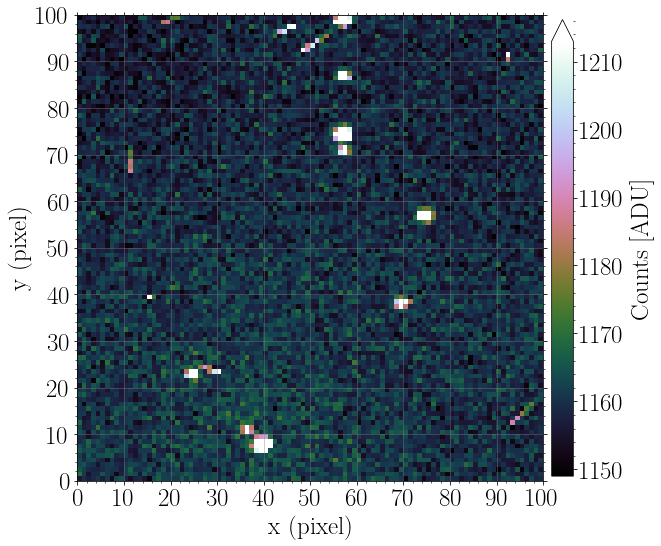

In [31]:
fig = simFile.showImage(0, clipPercentile=0.5, imgScale="clip",  
                  figsize=(10,10), fontSize=25, useTitle=False,
                  showStarPositions=False, showStarIDs=False,
                  colorMap="cubehelix", colorBar=True, showGrid=True) 